In [339]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from pathlib import Path
import warnings
import copy
import csv
import pandas as pd

from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
ROOT = Path("Amazon_products")
TRAIN_CORPUS_PATH = ROOT / "train" / "train_corpus.txt"
TEST_CORPUS_PATH  = ROOT / "test" / "test_corpus.txt"
CLASS_PATH = ROOT / "classes.txt"

EMB_DIR = Path("SilverGeneration/Embeddings")
X_ALL_PATH = EMB_DIR / "X_train_test_mpnet.pt" # Train + Test embeddings
LABEL_EMB_PATH = EMB_DIR / "labels_mpnet.pt"
LABEL_EMB_PATH2 = EMB_DIR / "labels_mpnet.pt"

MODEL_SAVE = Path("Models")
MODEL_SAVE.mkdir(exist_ok=True)
MODEL_PATH = MODEL_SAVE / "Linear.pt"

# Load useful data (like silver gen)
def load_classic(path):
    id2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            pid, text = line.strip().split("\t", 1)
            id2text[int(pid)] = text
    return id2text

id2text_train = load_classic(TRAIN_CORPUS_PATH)
id2text_test  = load_classic(TEST_CORPUS_PATH)
train_ids = list(id2text_train.keys())
test_ids  = list(id2text_test.keys())
print(test_ids)
n_train = len(train_ids)
n_test  = len(test_ids)
test_ids  = [n_train + i for i in range(n_test)]
print(test_ids)
print(f"Train IDs: {n_train} | Test IDs: {n_test}")

all_ids = train_ids + test_ids

# Load X_all + split into X_train & X_test
data = torch.load(X_ALL_PATH, weights_only=False)

# ensure tensor (check)
if isinstance(data, np.ndarray):
    data = torch.from_numpy(data)
elif isinstance(data, list):
    data = torch.stack(data)

X_all = data.float().to(device)

# Load Class names
classes = {}
with open(CLASS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cid, cname = line.strip().split("\t")
        classes[int(cid)] = cname

n_classes = len(classes) # 531
print(n_classes)

pid2idx = {pid: i for i, pid in enumerate(all_ids)}


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [340]:
class MultiLabelDataset(Dataset):
    def __init__(self, pids, labels_dict, scores_dict, n_classes):
        self.pids = pids
        self.labels_dict = labels_dict
        self.scores_dict = scores_dict
        self.n_classes = n_classes

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]

        # Embedding global
        emb = X_all[pid2idx[pid]]

        # Multi-hot vector with soft scores
        y = torch.zeros(self.n_classes)
        labels = self.labels_dict[pid]
        scores = self.scores_dict[pid]

        for c, s in zip(labels, scores):
            y[c] = float(s)

        return {
            "pid": pid,
            "X": emb,
            "y": y
        }
    

class UnlabeledEmbeddingDataset(Dataset):
    def __init__(self, pids):
        self.pids = pids

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_all[pid2idx[pid]]
        return {"X": emb, "pid": pid}


In [341]:
class InnerProductClassifier(nn.Module):
    def __init__(self, input_dim, label_emb, hidden_dim=512, dropout=0.3, trainable=True, scale=25):
        super().__init__()
        
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, label_emb.size(1))
        )
        
        self.scale = scale

        if trainable:
            self.label_emb = nn.Parameter(label_emb.clone())
        else:
            self.register_buffer("label_emb", label_emb.clone())

    def forward(self, x):
        x_proj = self.proj(x)
        
        # Normalisation
        x_norm = F.normalize(x_proj, dim=1)
        label_norm = F.normalize(self.label_emb, dim=1)

        # Inner product + scaling
        logits = x_norm @ label_norm.T
        logits = logits * self.scale
        
        return logits
    

class LabelGCNUpgrade(nn.Module):
    def __init__(self, emb_dim, num_layers=2, dropout=0.3, alpha=0.5, learn_alpha=False):
        super().__init__()
        self.dropout = dropout
        
        self.W_list = nn.ParameterList([
            nn.Parameter(torch.empty(emb_dim, emb_dim))
            for _ in range(num_layers)
        ])
        for W in self.W_list:
            nn.init.xavier_uniform_(W)

        if learn_alpha:
            self.alpha = nn.Parameter(torch.tensor(alpha))
        else:
            self.register_buffer("alpha", torch.tensor(alpha))

    def forward(self, H, A_hat):
        for i, W in enumerate(self.W_list):

            H_in = H
            H_msg = A_hat @ H_in @ W

            # SKIP CONNECTION
            H = H_in + self.alpha * H_msg

            if i < len(self.W_list) - 1:
                H = F.relu(H)
                H = F.dropout(H, p=self.dropout, training=self.training)

        return H


class GCNEnhancedClassifierUpgrade(nn.Module):
    def __init__(self, input_dim, label_init_emb, A_hat, parents_map=None,
                 num_layers=2, dropout=0.3, scale=25):
        super().__init__()
        self.dropout = dropout
        self.parents_map = parents_map if parents_map is not None else {}
        self.scale = scale

        emb_dim = label_init_emb.size(1)

        # --- PRE-PROCESSING MLP
        self.pre_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim)
        )
        self.encoder = LabelGCNUpgrade(
            emb_dim, num_layers=num_layers, dropout=dropout, alpha=0.5
        )
        self.proj = nn.Linear(input_dim, emb_dim)

        self.label_emb = nn.Parameter(label_init_emb.clone())
        self.register_buffer("A_hat", A_hat)

    def forward(self, x, return_label_emb=False):
        H0 = self.pre_mlp(self.label_emb)
        E_refine = self.encoder(H0, self.A_hat)
        x_proj = self.proj(x)

        x_norm = F.normalize(x_proj, dim=1)
        E_norm = F.normalize(E_refine, dim=1)

        logits = (x_norm @ E_norm.T) * self.scale

        if return_label_emb:
            return logits, E_refine

        return logits


def build_adj_from_hierarchy(class2children, n_classes, w_parent=1.0):
    A = torch.zeros((n_classes, n_classes))

    for parent, children in class2children.items():
        for c in children:
            if parent < n_classes and c < n_classes:
                A[parent, c] = 1.0
                A[c, parent] = 0.5

    A += torch.eye(n_classes)
    D = A.sum(dim=1)
    D_inv_sqrt = torch.pow(D, -0.5)
    D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0
    D_mat = torch.diag(D_inv_sqrt)

    return D_mat @ A @ D_mat

def load_multilabel(path):
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p, c = map(int, line.strip().split("\t"))
            id2labels.setdefault(p, []).append(c)
    return id2labels

CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

A_hat = build_adj_from_hierarchy(class2hierarchy, n_classes).to(device)
print("A_hat:", A_hat.shape, "Non-zero =", (A_hat > 0).sum().item())

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

parents_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIERARCHY_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)  
print("Parents of 1:", parents_map[1])
print(A_hat)

A_hat: torch.Size([531, 531]) Non-zero = 1667
Label embeddings: torch.Size([531, 768])
Parents of 1: [0]
tensor([[0.0588, 0.0832, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0416, 0.1176, 0.2801,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1400, 0.6667,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.6667, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.6667, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.6667]],
       device='cuda:0')


In [342]:
# Evaluation metrics -> see paper given
def precision_at_1(y_true, scores):
    correct = 0
    for yt, sc in zip(y_true, scores):
        top1 = sc.argmax()
        if yt[top1] == 1:
            correct += 1
    return correct / len(y_true)


def precision_at_3(y_true, scores):
    total_correct = 0
    for yt, sc in zip(y_true, scores):
        top3 = sc.argsort()[-3:][::-1]
        total_correct += yt[top3].sum()
    return total_correct / (3 * len(y_true))


def evaluate_topk_full(model, loader, k=3):
    model.eval()
    
    all_scores = []
    all_true = []
    preds_bin = []

    with torch.no_grad():
        for batch in loader:
            X = batch["X"].to(device)
            y = batch["y"].cpu().numpy()         

            y_bin = (y > 0).astype(int)         

            logits = model(X)
            prob = torch.sigmoid(logits).cpu().numpy()

            all_scores.extend(prob)
            all_true.extend(y_bin)              

            # --- TOP-K prediction ---
            topk_idx = np.argsort(-prob, axis=1)[:, :k]
            pred_bin = np.zeros_like(prob, dtype=int)

            for i in range(prob.shape[0]):
                pred_bin[i, topk_idx[i]] = 1

            preds_bin.extend(pred_bin)

    preds_bin = np.array(preds_bin)
    all_true = np.array(all_true)
    all_scores = np.array(all_scores)

    f1s = f1_score(all_true, preds_bin, average="samples")
    f1m = f1_score(all_true, preds_bin, average="macro")
    p1 = precision_at_1(all_true, all_scores)
    p3 = precision_at_3(all_true, all_scores)

    return f1s, f1m, p1, p3


In [343]:
# Helpers

CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"

def load_multilabel(path):
    """Load multi-label data into {id: [labels]} dictionary -> for class_hierarchy"""
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                pid, label = parts
                pid = int(pid)
                label = int(label)
                if pid not in id2labels:
                    id2labels[pid] = []
                id2labels[pid].append(label)
    return id2labels
    
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

pairs = []
for parent, children in class2hierarchy.items():
    for c in children:
        pairs.append((parent, c))

# roots
parents = set(p for p, c in pairs)
children = set(c for p, c in pairs)
roots = sorted(parents - children)

print(roots)

def load_parent_map(path):
    """
    Returns:
        parent_map = {parent: [child1, child2, ...]}
    """
    parent_map = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parent, child = line.strip().split("\t")
            parent = int(parent)
            child = int(child)

            if parent not in parent_map:
                parent_map[parent] = []
            parent_map[parent].append(child)

    return parent_map

parents_map = {i: [] for i in range(n_classes)}
children_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIERARCHY_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)  
        children_map[p].append(c)    
print("Parents of 1:", parents_map[1])
print("Children of 0:", children_map[0])

[0, 3, 10, 23, 40, 169]
Parents of 1: [0]
Children of 0: [1, 8, 208, 211, 213, 216, 229, 255, 265, 218, 271, 277, 249, 288, 313, 357]


In [344]:
def hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=1.0):
    """
    Force: p[parent] >= 0.8 * p[child]
    """
    probs = torch.sigmoid(logits) 
    
    p = probs[:, parent_idx]        
    c = probs[:, child_idx]       

    # Parent doit être >= 80% du child
    penalty = F.relu(0.8 * c - p)

    return alpha * penalty.mean()

hier_pairs = []
for child, parents in parents_map.items():
    for p in parents:
        hier_pairs.append((p, child))

parent_idx = torch.tensor([p for p, c in hier_pairs], device=device)
child_idx  = torch.tensor([c for p, c in hier_pairs], device=device)
print(parent_idx)

tensor([  0,   1,   3,   3,   5,   4,   0,   8,  10,  11,   3,  13,   3,  15,
          3,  17,   4,  13,   3,  21,  23,  24,  23,  26,   3,  28,   3,  23,
         31,  21,   3,   3,  35,  13,  23,  38,  40,  41,  24,  10, 145,  11,
         44,  34,  24,  21,  24,   3,   3,  51,   3,  10,  54,  15,  17,   5,
         17,  24,  10,  60,  24,  38,  10,  64,  30,  11,  44,  53,  11,  44,
          4,  24,  38,  44,  44,  23,  74,  23,  31,  38,  64,  64,  30,  38,
         54,  74,   3,  85,  38,  38,  26,  64,  38,  60,  64,  38,  54,  31,
          5,  38,  53,  40, 100,  21,  38,  30,  23, 105,  38,  21,  11,  53,
          3, 111,  28, 111,  21,  34,  30,  74, 111,   3, 120,  13, 111,  21,
        111,  21,  21,  40, 128, 128,  40, 131,   5, 131,  40, 135,  38, 135,
         40, 139, 135, 131,  34,  15,  40, 145,   3, 147,  41,  13,  40, 151,
        139,  21, 139, 147, 120,  85, 131,  40, 111,  40, 162,  21,  74,  15,
        151, 160, 147,  17, 169, 170, 199,  21,  44,  54,   4, 1

In [345]:
def select_k(prob, min_k=2, max_k=3):
    idx = np.argsort(prob)[::-1]
    top3 = idx[:max_k]
    if prob[top3[2]] < 0.50 * prob[top3[1]]:
        return top3[:2]
    return top3

# Comparison with real results

def load_csv_labels(path):
    """
    Load a CSV file formatted as:
    id,label1 label2 label3
    Returns {id: [labels]}
    """
    out = {}
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pid = int(row["id"])
            labels = [int(x) for x in row["label"].replace(",", " ").split()]
            out[pid] = labels
    return out


def score_submission_csv(pred_path, gold_path):
    """
    Score a submission CSV using your GOLD CSV.
    Computes: F1 (samples), P@1, P@3
    """
    pred = load_csv_labels(pred_path)
    gold = load_csv_labels(gold_path)

    # Sorted IDs intersection
    ids = sorted(set(pred.keys()) & set(gold.keys()))

    num_classes = 531

    Y_true = []
    Y_pred = []
    Y_scores = []

    for pid in ids:
        true_vec  = np.zeros(num_classes)
        pred_vec  = np.zeros(num_classes)
        score_vec = np.zeros(num_classes)

        true_vec[gold[pid]] = 1
        pred_vec[pred[pid]] = 1
        score_vec[pred[pid]] = 1.0

        Y_true.append(true_vec)
        Y_pred.append(pred_vec)
        Y_scores.append(score_vec)

    f1s = f1_score(Y_true, Y_pred, average="samples")
    P1 = precision_at_1(Y_true, Y_scores)
    P3 = precision_at_3(Y_true, Y_scores)

    print(f"Sample F1 : {f1s:.4f}")
    print(f"P@1 : {P1:.2f}")
    print(f"P@3 : {P3:.2f}")

In [346]:
CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"

def load_multilabel(path):
    """Load multi-label data into {id: [labels]} dictionary -> for class_hierarchy"""
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                pid, label = parts
                pid = int(pid)
                label = int(label)
                if pid not in id2labels:
                    id2labels[pid] = []
                id2labels[pid].append(label)
    return id2labels
    
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

pairs = []
for parent, children in class2hierarchy.items():
    for c in children:
        pairs.append((parent, c))

# roots
parents = set(p for p, c in pairs)
children = set(c for p, c in pairs)
roots = sorted(parents - children)

print(roots)

[0, 3, 10, 23, 40, 169]


In [347]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import Counter

def tsne_visualize(X_all, all_ids, current_labels, current_scores, TOP_K=20, N=4000):
    """
    Reproduce EXACT t-SNE visualization pipeline you executed earlier.
    Same ROOT_SET, colors, mapping, filtering, style.
    """
    refined = {
        pid: {"labels": labs, "scores": current_scores[pid]}
        for pid, labs in current_labels.items()
    }

    X = X_all.cpu().numpy()
    idx = np.random.choice(len(X), size=min(N, len(X)), replace=False)
    X_sub = X[idx]
    ids_subset = np.array(all_ids)[idx]

    ROOT_SET = {0, 3, 10, 23, 40, 169}

    leaf_labels = []
    root_labels = []

    for pid in ids_subset:
        entry = refined.get(pid)

        if entry:
            labs = entry["labels"]
            leaf = labs[0]
            root = next((x for x in labs if x in ROOT_SET), -1)
        else:
            leaf = root = -1

        leaf_labels.append(leaf)
        root_labels.append(root)

    leaf_labels = np.array(leaf_labels)
    root_labels = np.array(root_labels)

    cnt = Counter(leaf_labels[leaf_labels >= 0])
    top_leafs = set([lab for lab, _ in cnt.most_common(TOP_K)])

    print(f"Top-{TOP_K} leaf classes:", cnt.most_common(TOP_K))

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_emb = tsne.fit_transform(X_sub)

    plt.figure(figsize=(10, 8))

    mask_other = np.array([l not in top_leafs for l in leaf_labels])
    mask_top = ~mask_other

    # Others in light gray
    plt.scatter(X_emb[mask_other,0], X_emb[mask_other,1],
                s=5, alpha=0.15, color="lightgray", label="Other classes")

    # Remapping TOP-K into compact range
    unique_top = sorted(top_leafs)
    mapping = {lab: i for i, lab in enumerate(unique_top)}
    compact = np.array([mapping.get(l, -1) for l in leaf_labels])

    # TOP-K in tab20 (same style as before)
    plt.scatter(X_emb[mask_top,0], X_emb[mask_top,1],
                s=12, c=compact[mask_top], cmap="tab20",
                label=f"Top {TOP_K} leaf classes")

    plt.title(f"t-SNE — Top-{TOP_K} most represented leaf classes")
    plt.legend()
    plt.show()

    print("TSNE visualization completed.")

In [ ]:
test_set = set(test_ids)

with open("SilverGeneration/SilverCombo/pseudo_silver_all_Remake.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

silver_labels = {int(pid): data["labels"] for pid, data in raw.items()}
silver_scores = {int(pid): data["scores"] for pid, data in raw.items()}

with open("SilverGeneration/SilverCombo/pseudo_gold_all_Remake.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

gold_labels = {int(pid): data["labels"] for pid, data in raw.items()}
gold_scores = {int(pid): data["scores"] for pid, data in raw.items()}

silver_labels = {pid: lab for pid, lab in silver_labels.items() if pid not in gold_labels}
silver_scores = {pid: sc for pid, sc in silver_scores.items() if pid not in gold_labels}

print("Silver remaining:", len(silver_labels))
print("Gold:", len(gold_labels))

all_gold_ids = list(gold_labels.keys())

gold_train, gold_val = train_test_split(all_gold_ids, test_size=0.2, random_state=42)

print("Train GOLD:", len(gold_train))
print("Val GOLD:", len(gold_val))

train_labels = {pid: gold_labels[pid] for pid in gold_train}
train_scores = {pid: gold_scores[pid] for pid in gold_train}

val_labels = {pid: gold_labels[pid] for pid in gold_val}
val_scores = {pid: gold_scores[pid] for pid in gold_val}

print("TRAIN gold samples:", len(train_labels))
print("VAL gold samples:", len(val_labels))

all_train_ids = list(range(n_train + n_test))
used_ids = set(gold_train) | set(gold_val)
unlabeled_ids = list(set(all_train_ids) - used_ids)

print("UNLABELED count:", len(unlabeled_ids))

train_dataset = MultiLabelDataset(gold_train, train_labels, train_scores, n_classes)
val_dataset = MultiLabelDataset(gold_val, val_labels, val_scores, n_classes)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Total unlabeled:", len(unlabeled_ids))


Silver remaining: 25132
Gold: 12411
Train GOLD: 9928
Val GOLD: 2483
TRAIN gold samples: 9928
VAL gold samples: 2483
UNLABELED count: 36734
Train dataset size: 9928
Val dataset size: 2483
Total unlabeled: 36734


9928
Top-20 leaf classes: [(3, 163), (40, 108), (169, 105), (10, 95), (0, 79), (23, 69), (220, 31), (24, 18), (8, 18), (93, 13), (26, 13), (4, 11), (43, 9), (170, 8), (15, 8), (131, 7), (32, 6), (135, 6), (118, 5), (74, 5)]


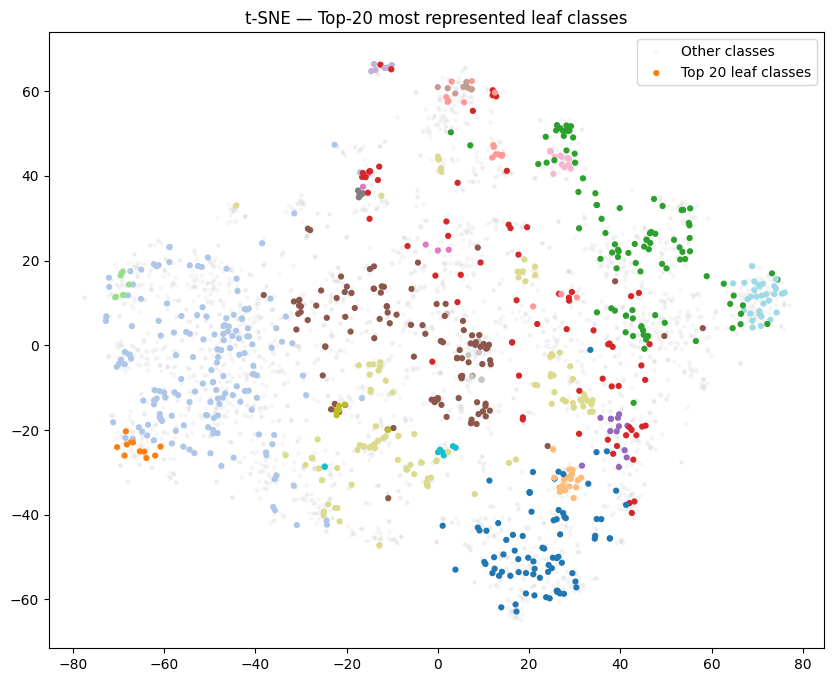

TSNE visualization completed.


In [349]:
current_labels = train_labels
all_ids = train_ids + test_ids
current_scores = train_scores
print(len(current_labels))
tsne_visualize(X_all, all_ids, current_labels, current_scores)


In [350]:
def get_lambda_cons(epoch, warmup, max_epochs):
    if epoch <= warmup:
        return 0.0
    else:
        progress = (epoch - warmup) / (max_epochs - warmup)
        return 7.5 * (1 + progress)  # 7.5 → 15.0

In [351]:
def focal_bce(logits, targets, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    pt = torch.exp(-bce)
    return (((1 - pt) ** gamma) * bce).mean()

In [ ]:
# Hyperparameters
num_epochs = 100
batch_size = 64

learning_rate = 2e-4
dropout_rate = 0.5
noise_std = 0.10
grad_clip_value = 0.1

# Consistency
max_consistency = 1.0
consistency_warmup = 5
consistency_conf_threshold = 0.8

# Pseudo-labeling
pseudo_warmup = 10
pseudo_add_freq = 5
pseudo_check_freq = 5
max_pseudo_per_step = 1000
min_pseudo_conf = 0.6
num_top_classes = 2

# EMA teacher
ema_alpha = 0.99
early_stopping_patience = 15

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

student = InnerProductClassifier(input_dim=X_all.size(1),label_emb=label_emb,dropout=dropout_rate,trainable=True,scale=15).to(device)
teacher = InnerProductClassifier(input_dim=X_all.size(1),label_emb=label_emb,dropout=0.0,trainable=True,scale=15).to(device)

"""To_try
student = InnerProductClassifier(input_dim=X_all.size(1),label_emb=label_emb,dropout=dropout_rate,trainable=True,scale=15).to(device)
teacher = InnerProductClassifier(input_dim=X_all.size(1),label_emb=label_emb,dropout=0.0,trainable=True,scale=15).to(device)

student = GCNEnhancedClassifierUpgrade(input_dim=X_all.size(1),label_init_emb=label_emb,A_hat=A_hat, parents_map=parents_map, num_layers=2,dropout=dropout_rate,scale=25).to(device)
teacher = GCNEnhancedClassifierUpgrade(input_dim=X_all.size(1),label_init_emb=label_emb,A_hat=A_hat, parents_map=parents_map, num_layers=2,dropout=0.0,scale=25).to(device)
"""

teacher.load_state_dict(student.state_dict())


optimizer = torch.optim.Adam([
    {"params": student.proj.parameters(), "lr": learning_rate},
])

initial_silver = set(current_labels.keys())   # NE JAMAIS TOUCHER
pseudo_added = set()

unlabeled = set(all_ids) - set(gold_val) - set(gold_train)

print(f"Initial labeled: {len(current_labels)}")
print(f"Initial val: {len(val_dataset)}")
print(f"Initial unlabeled: {len(unlabeled)}")

best_f1m = 0.0
best_state = None
wait = 0


for epoch in range(1, num_epochs + 1):
    if epoch <= consistency_warmup:
        consistency_weight = 0.0
    else:
        progress = (epoch - consistency_warmup) / (num_epochs - consistency_warmup)
        consistency_weight = max_consistency * float(np.clip(progress, 0.0, 1.0))

    print(f"\nEpoch {epoch}/{num_epochs} | labeled={len(current_labels)} | unlabeled={len(unlabeled)}")

    student.train()

    # Build labeled loader
    labeled_ids = list(current_labels.keys())
    train_dataset = MultiLabelDataset(labeled_ids, current_labels, current_scores, n_classes)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Build unlabeled loader
    if len(unlabeled) > 0:
        unl_dataset = UnlabeledEmbeddingDataset(list(unlabeled))
        unl_loader = DataLoader(unl_dataset, batch_size=batch_size, shuffle=True)
        unl_iter = iter(unl_loader)
    else:
        unl_loader = None

    # Tracking losses
    total_sup_loss = 0.0
    total_cons_loss = 0.0
    num_cons_batches = 0


    for batch in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):

        X = batch["X"].to(device)
        y = batch["y"].to(device)

        # Noise augmentation
        noisy_X = X + torch.randn_like(X) * noise_std

        # supervised loss
        logits = student(noisy_X)
        sup_loss = focal_bce(logits, y, gamma=2.0)

        loss = sup_loss
        total_sup_loss += sup_loss.item()


        # consistency loss
        if consistency_weight > 0 and unl_loader is not None:

            try:
                batch_u = next(unl_iter)
            except StopIteration:
                unl_iter = iter(unl_loader)
                batch_u = next(unl_iter)

            Xu = batch_u["X"].to(device)

            with torch.no_grad():
                teacher_pred = torch.sigmoid(teacher(Xu))

            mask = ((teacher_pred >= consistency_conf_threshold) |
                    (teacher_pred <= 1 - consistency_conf_threshold)).float()

            Xu_noisy = Xu + torch.randn_like(Xu) * noise_std
            student_pred = torch.sigmoid(student(Xu_noisy))

            if mask.sum() > 0:
                cons_loss = ((student_pred - teacher_pred) ** 2 * mask).sum() / mask.sum()
            else:
                cons_loss = torch.tensor(0.0, device=device)

            loss += consistency_weight * cons_loss
            total_cons_loss += cons_loss.item()
            num_cons_batches += 1


        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), grad_clip_value)
        optimizer.step()


    with torch.no_grad():
        for t, s in zip(teacher.parameters(), student.parameters()):
            t.data = ema_alpha * t.data + (1 - ema_alpha) * s.data

    num_batches = max(1, len(train_loader))
    avg_sup = total_sup_loss / num_batches
    avg_cons = total_cons_loss / max(num_cons_batches, 1)

    # Contribution of each loss
    total_combined = avg_sup + avg_cons * consistency_weight

    sup_pct = 100 * avg_sup / total_combined
    cons_pct = 100 * (avg_cons * consistency_weight) / total_combined

    print(f"Loss supervision : {avg_sup:.4f}  ({sup_pct:.1f}%)")
    print(f"Loss consistance : {avg_cons:.4f} * {consistency_weight:.2f} = {(avg_cons*consistency_weight):.4f}  ({cons_pct:.1f}%)")

    teacher.eval()
    f1s, f1m, p1, p3 = evaluate_topk_full(teacher, val_loader)
    print(f"F1m={f1m:.4f} | P@1={p1:.3f}")


    # Early stopping
    if f1m > best_f1m:
        best_f1m = f1m
        best_state = teacher.state_dict()
        wait = 0
        torch.save(best_state, MODEL_PATH)
    else:
        wait += 1
        if wait >= early_stopping_patience:
            print("Early stopping triggered")
            break

    # remove labels
    if epoch >= pseudo_warmup and epoch % pseudo_check_freq == 0:


        with torch.no_grad():
            probs_all = torch.sigmoid(teacher(X_all.to(device))).cpu().numpy()

        to_remove = []
        for pid in list(pseudo_added):
            if probs_all[pid2idx[pid]].max() < min_pseudo_conf:
                to_remove.append(pid)

        for pid in to_remove:
            del current_labels[pid]
            del current_scores[pid]
            pseudo_added.remove(pid)
            unlabeled.add(pid)

        print(f"Removed {len(to_remove)} pseudo-labels")

    # add PS
    if epoch >= pseudo_warmup and epoch % pseudo_add_freq == 0 and len(unlabeled) > 0:

        with torch.no_grad():
            u_list = list(unlabeled)
            idxs = torch.tensor([pid2idx[p] for p in u_list], device=device)
            probs = torch.sigmoid(teacher(X_all[idxs])).cpu().numpy()

        conf = probs.max(axis=1)
        order = np.argsort(-conf)

        added = 0
        for k in order:
            if added >= max_pseudo_per_step:
                break

            pid = u_list[k]
            pred = probs[k]

            best = pred.argsort()[-num_top_classes:][::-1]

            labels = []
            scores = []

            for rank, cls in enumerate(best):
                score = pred[cls]

                if score < min_pseudo_conf:
                    continue

                labels.append(int(cls))
                scores.append(float(score))

                if cls in parents_map:
                    parent_list = parents_map.get(cls, [])
                    if not parent_list:
                        continue

                    parent_probs = [(p, pred[p]) for p in parent_list]
                    best_parent, parent_prob = max(parent_probs, key=lambda x: x[1])

                    if parent_prob >= min_pseudo_conf * 0.7 and best_parent not in labels:
                        labels.append(int(best_parent))
                        scores.append(float(parent_prob))

            if len(labels) == 0:
                continue


            current_labels[pid] = labels
            current_scores[pid] = scores
            pseudo_added.add(pid)
            unlabeled.remove(pid)
            added += 1

        print(f"Added {added} | Unlabeled now: {len(unlabeled)}")

# Restore best EMA model
if best_state is not None:
    teacher.load_state_dict(best_state)
    print(f"Best F1m={best_f1m:.4f}")

teacher.eval()


Label embeddings: torch.Size([531, 768])
Initial labeled: 9928
Initial val: 2483
Initial unlabeled: 36734

Epoch 1/100 | labeled=9928 | unlabeled=36734


Loss supervision : 0.0142  (100.0%)
Loss consistance : 0.0000 * 0.00 = 0.0000  (0.0%)
F1m=0.0004 | P@1=0.003

Epoch 2/100 | labeled=9928 | unlabeled=36734


Loss supervision : 0.0060  (100.0%)
Loss consistance : 0.0000 * 0.00 = 0.0000  (0.0%)
F1m=0.0007 | P@1=0.010

Epoch 3/100 | labeled=9928 | unlabeled=36734


Loss supervision : 0.0053  (100.0%)
Loss consistance : 0.0000 * 0.00 = 0.0000  (0.0%)
F1m=0.0016 | P@1=0.053

Epoch 4/100 | labeled=9928 | unlabeled=36734


Loss supervision : 0.0049  (100.0%)
Loss consistance : 0.0000 * 0.00 = 0.0000  (0.0%)
F1m=0.0026 | P@1=0.129

Epoch 5/100 | labeled=9928 | unlabeled=36734


...

Loss supervision : 0.0039  (81.5%)
Loss consistance : 0.0009 * 0.97 = 0.0009  (18.5%)
F1m=0.0281 | P@1=0.843

Epoch 98/100 | labeled=11214 | unlabeled=35448


Loss supervision : 0.0040  (81.3%)
Loss consistance : 0.0009 * 0.98 = 0.0009  (18.7%)
F1m=0.0280 | P@1=0.843

Epoch 99/100 | labeled=11214 | unlabeled=35448


Loss supervision : 0.0040  (81.5%)
Loss consistance : 0.0009 * 0.99 = 0.0009  (18.5%)
F1m=0.0281 | P@1=0.842

Epoch 100/100 | labeled=11214 | unlabeled=35448


Loss supervision : 0.0040  (81.5%)
Loss consistance : 0.0009 * 1.00 = 0.0009  (18.5%)
F1m=0.0282 | P@1=0.842
Removed 29 pseudo-labels
Added 5 | Unlabeled now: 35472
Best F1m=0.0282


GCNEnhancedClassifierUpgrade(
  (pre_mlp): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=768, out_features=768, bias=True)
  )
  (encoder): LabelGCNUpgrade(
    (W_list): ParameterList(
        (0): Parameter containing: [torch.float32 of size 768x768 (cuda:0)]
        (1): Parameter containing: [torch.float32 of size 768x768 (cuda:0)]
    )
  )
  (proj): Linear(in_features=768, out_features=768, bias=True)
)

In [353]:
with torch.no_grad():
    E_norm = F.normalize(teacher.label_emb, dim=1)
    
    improvements = []
    print("\nParent-Child Cosine Similarities:")
    for i, (child, parents) in enumerate(parents_map.items()):
        if len(parents) > 0 and i < 10:
            parent = parents[0]
            sim = (E_norm[child] @ E_norm[parent]).item()
            improvements.append(sim)
    
    avg_hier = sum(improvements) / len(improvements)
    print(f"\nAverage parent-child: {avg_hier:.3f}")
    
    random_sims = []
    for _ in range(2000):
        i, j = torch.randint(0, len(E_norm), (2,))
        if i != j:
            random_sims.append((E_norm[i] @ E_norm[j]).item())
    
    avg_random = sum(random_sims) / len(random_sims)
    print(f"Average random pairs: {avg_random:.3f}")
    print(f"Hierarchy boost: {avg_hier - avg_random:+.3f}")


Parent-Child Cosine Similarities:

Average parent-child: 0.809
Average random pairs: 0.435
Hierarchy boost: +0.374


In [354]:
print("Test count:", len(test_ids))
# Eval mode
teacher.eval()

preds = []
batch_size = 64

with torch.no_grad():
    for b_start in tqdm(range(0, len(test_ids), batch_size)):
        batch_pids = test_ids[b_start:b_start + batch_size]

        batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

        logits = teacher(batch_emb)
        probs = torch.sigmoid(logits).cpu().numpy()

        for p in probs:
            labels = select_k(p)
            preds.append([str(x) for x in labels])


# Save submission
OUT_DIR = Path("Submission")
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "submission_self_training.csv"

with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "label"])
    for pid, labels in zip(test_ids, preds):
        true_test_id = pid - n_train
        w.writerow([true_test_id, ",".join(labels)])

print(f"Submission saved -> {OUT_PATH}")


Test count: 19658


100%|██████████| 308/308 [00:00<00:00, 318.16it/s]

Submission saved -> Submission\submission_self_training.csv


Top-20 leaf classes: [(3, 246), (10, 92), (40, 88), (23, 88), (0, 84), (169, 82), (220, 27), (24, 21), (43, 14), (8, 11), (170, 11), (26, 10), (15, 9), (31, 8), (4, 8), (135, 5), (32, 5), (64, 5), (131, 5), (93, 4)]


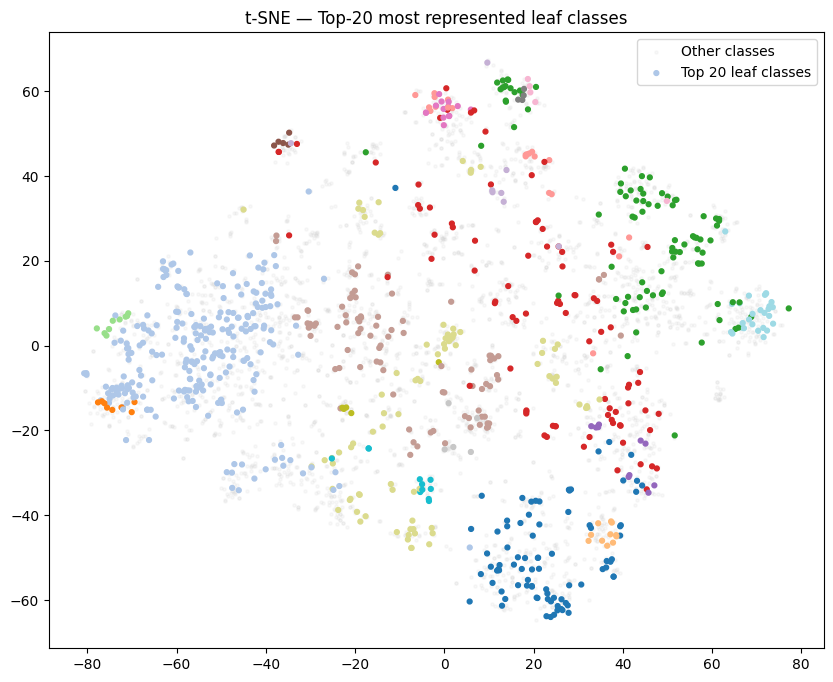

TSNE visualization completed.


In [355]:
tsne_visualize(X_all, all_ids, current_labels, current_scores)



Graph


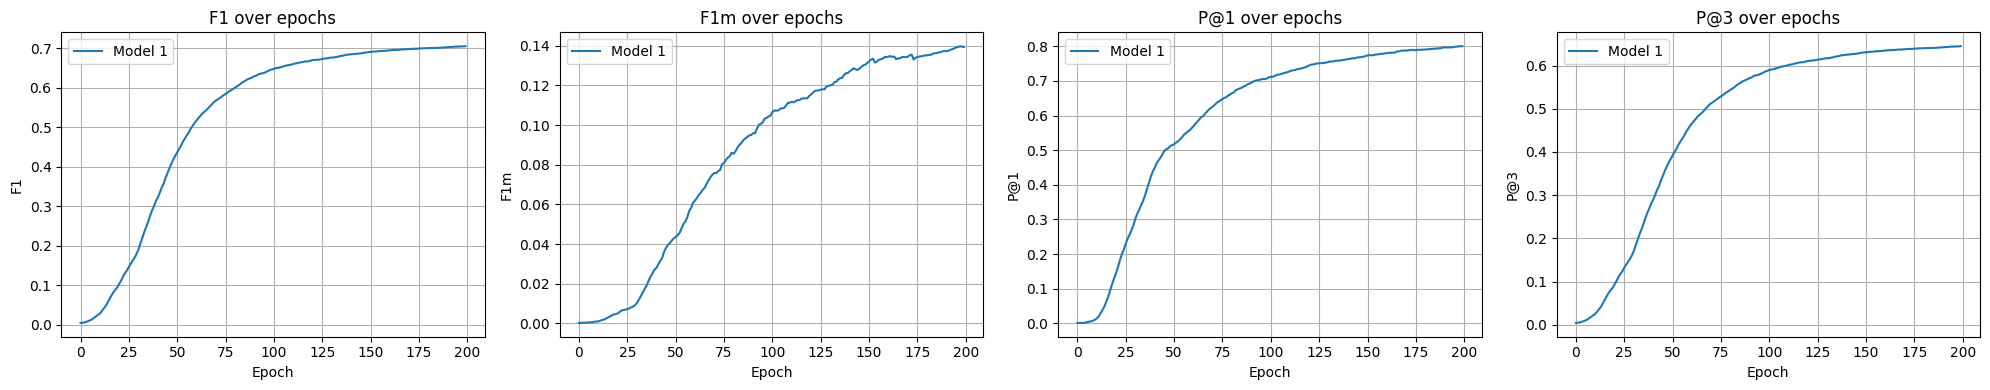

In [356]:
import matplotlib.pyplot as plt

def plot_all_metrics(results_dict):
    """
    results_dict must have the form:
    {
        "F1":  {"loss1": [...], "loss2": [...]},
        "F1m": {"loss1": [...], "loss2": [...]},
        "P@1": {"loss1": [...], "loss2": [...]},
        "P@3": {"loss1": [...], "loss2": [...]},
    }
    """

    metrics = ["F1", "F1m", "P@1", "P@3"]
    plt.figure(figsize=(20, 4))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 4, i + 1)

        if metric not in results_dict:
            plt.title(metric + " (missing)")
            continue

        for model_name, values in results_dict[metric].items():
            plt.plot(values, label=model_name)

        plt.title(metric + " over epochs")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


results = {
    "F1": {
        "Model 1": l1,
    },
    "F1m": {
        "Model 1": l2,
    },
    "P@1": {
        "Model 1": l3,
    },
    "P@3": {
        "Model 1": l4,
    }
}

print("\nGraph")
plot_all_metrics(results)

In [357]:
score_submission_csv(
    pred_path="Submission/submission_gnn_st.csv",
    gold_path="Gold/gold.csv"
)

Sample F1 : 0.6533
P@1 : 0.80
P@3 : 0.60
